# Разведочный анализ данных

Первым делом смотрю на что вообще похожи данные: сколько мошенничеств, как выглядят признаки, есть ли что-то очевидное.

**Данные:** 284 807 транзакций европейских держателей карт, сентябрь 2013. Признаки V1–V28 анонимизированы через PCA — что за ними стоит, неизвестно. Целевая переменная: Class (0 — легитимная, 1 — мошенничество).

**Выводы:** Сильный дисбаланс — 0.17% мошенничеств (492 из 284 807). Мошеннические транзакции имеют меньший Amount и специфичные паттерны в V4, V11, V14, V17. Пропусков нет. Accuracy как метрика бесполезна — нужен PR-AUC.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')

DATA_PATH = '../data/creditcard.csv'

df = pd.read_csv(DATA_PATH)
print(f'Форма датасета: {df.shape}')
df.head(3)

Форма датасета: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0


## Базовая информация о датасете

In [2]:
print('=== Типы данных ===')
print(df.dtypes)
print(f'\n=== Пропуски ===')
print(df.isnull().sum())
print(f'\nИтого пропусков: {df.isnull().sum().sum()}')

=== Типы данных ===
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

=== Пропуски ===
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

Итог

In [3]:
print('=== Базовая статистика ===')
df[['Time', 'Amount', 'Class']].describe()

=== Базовая статистика ===


,Time,Amount,Class
count,284807.000000,284807.000000,284807.000000
mean,94813.859575,88.349619,0.001727
std,47488.145955,250.120109,0.041527
min,0.000000,0.000000,0.000000
25%,54201.500000,5.600000,0.000000
50%,84692.000000,22.000000,0.000000
75%,139320.500000,77.165000,0.000000
max,172792.000000,25691.160000,1.000000


## Дисбаланс классов

Самое важное что нужно понять с самого начала.

Распределение классов:
  Легитимные (0): 284,315 (99.83%)
  Мошеннические (1): 492 (0.1727%)

Соотношение дисбаланса: 1 : 577


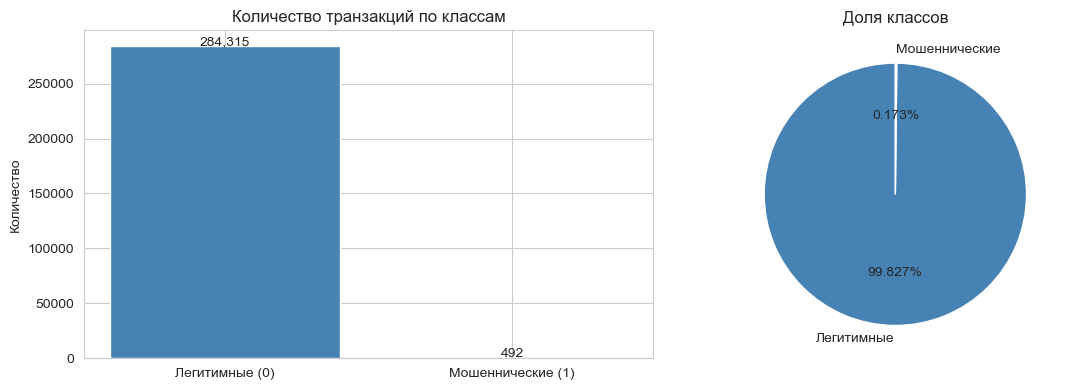


Вывод: сильный дисбаланс — accuracy бесполезна, используем PR-AUC


In [4]:
class_counts = df['Class'].value_counts()
class_pct = df['Class'].value_counts(normalize=True) * 100

print('Распределение классов:')
print(f'  Легитимные (0): {class_counts[0]:,} ({class_pct[0]:.2f}%)')
print(f'  Мошеннические (1): {class_counts[1]:,} ({class_pct[1]:.4f}%)')
print(f'\nСоотношение дисбаланса: 1 : {class_counts[0] // class_counts[1]}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['Легитимные (0)', 'Мошеннические (1)'], class_counts.values,
            color=['steelblue', 'tomato'])
axes[0].set_title('Количество транзакций по классам')
axes[0].set_ylabel('Количество')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center')

axes[1].pie(class_counts.values, labels=['Легитимные', 'Мошеннические'],
            colors=['steelblue', 'tomato'], autopct='%1.3f%%', startangle=90)
axes[1].set_title('Доля классов')

plt.tight_layout()
plt.savefig('../artifacts/class_distribution.png', dpi=100, bbox_inches='tight')
plt.show()
print('\nВывод: сильный дисбаланс — accuracy бесполезна, используем PR-AUC')

## Amount и Time

Посмотрим отличаются ли суммы и время транзакций у мошенников и обычных пользователей.

=== Amount ===
Легитимные:     медиана=22.00, среднее=88.29, макс=25691.16
Мошеннические:  медиана=9.25, среднее=122.21, макс=2125.87


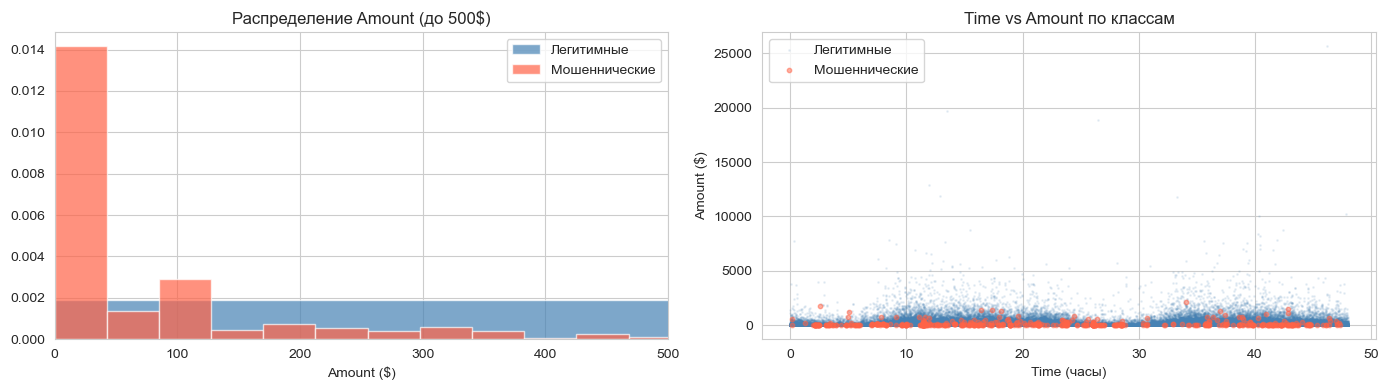

In [5]:
fraud = df[df['Class'] == 1]
legit = df[df['Class'] == 0]

print('=== Amount ===')
print(f'Легитимные:     медиана={legit["Amount"].median():.2f}, среднее={legit["Amount"].mean():.2f}, макс={legit["Amount"].max():.2f}')
print(f'Мошеннические:  медиана={fraud["Amount"].median():.2f}, среднее={fraud["Amount"].mean():.2f}, макс={fraud["Amount"].max():.2f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(legit['Amount'], bins=50, alpha=0.7, color='steelblue', label='Легитимные', density=True)
axes[0].hist(fraud['Amount'], bins=50, alpha=0.7, color='tomato', label='Мошеннические', density=True)
axes[0].set_xlim(0, 500)
axes[0].set_title('Распределение Amount (до 500$)')
axes[0].set_xlabel('Amount ($)')
axes[0].legend()

axes[1].scatter(legit['Time'] / 3600, legit['Amount'], alpha=0.1, s=1, color='steelblue', label='Легитимные')
axes[1].scatter(fraud['Time'] / 3600, fraud['Amount'], alpha=0.5, s=10, color='tomato', label='Мошеннические')
axes[1].set_title('Time vs Amount по классам')
axes[1].set_xlabel('Time (часы)')
axes[1].set_ylabel('Amount ($)')
axes[1].legend()

plt.tight_layout()
plt.savefig('../artifacts/amount_time_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

## Информативность признаков V1–V28

Поскольку признаки анонимны, оценю их полезность через корреляцию с таргетом.

Топ-10 признаков по |корреляции| с Class:
V17    0.326
V14    0.303
V12    0.261
V10    0.217
V16    0.197
V3     0.193
V7     0.187
V11    0.155
V4     0.133
V18    0.111
dtype: float64


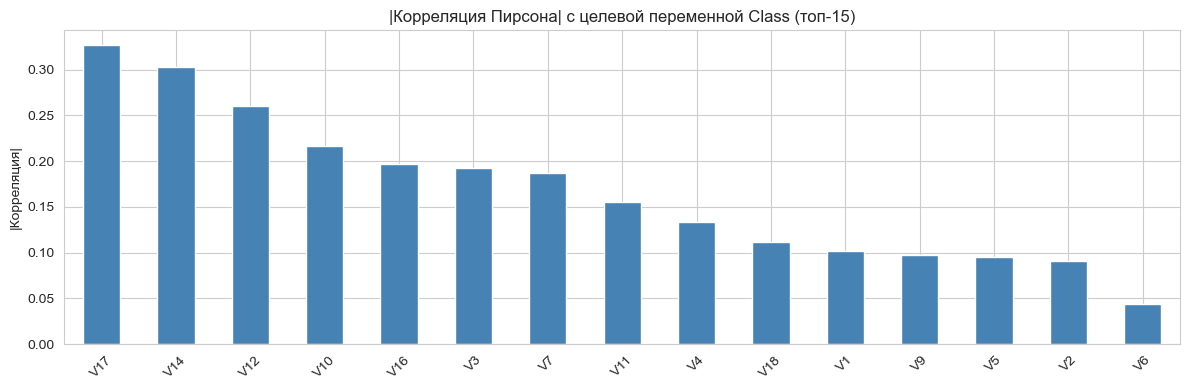

In [6]:
v_features = [f'V{i}' for i in range(1, 29)]

correlations = df[v_features + ['Amount']].corrwith(df['Class']).abs().sort_values(ascending=False)

print('Топ-10 признаков по |корреляции| с Class:')
print(correlations.head(10).round(3))

plt.figure(figsize=(12, 4))
correlations.head(15).plot(kind='bar', color='steelblue')
plt.title('|Корреляция Пирсона| с целевой переменной Class (топ-15)')
plt.ylabel('|Корреляция|')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../artifacts/feature_correlations.png', dpi=100, bbox_inches='tight')
plt.show()

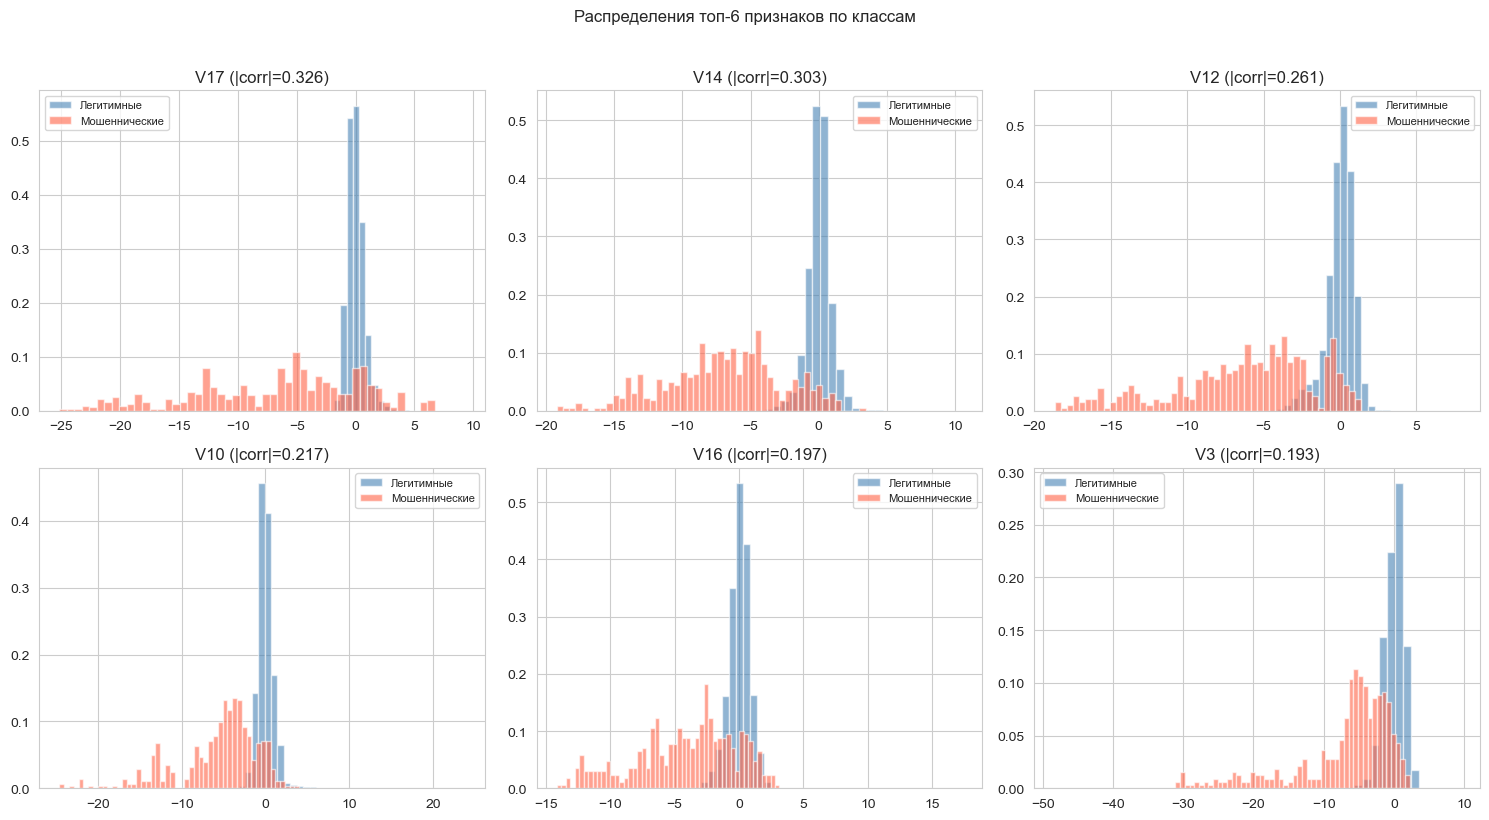

In [7]:
top_features = correlations.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    axes[i].hist(legit[feat], bins=50, alpha=0.6, color='steelblue', label='Легитимные', density=True)
    axes[i].hist(fraud[feat], bins=50, alpha=0.6, color='tomato', label='Мошеннические', density=True)
    axes[i].set_title(f'{feat} (|corr|={correlations[feat]:.3f})')
    axes[i].legend(fontsize=8)

plt.suptitle('Распределения топ-6 признаков по классам', y=1.02)
plt.tight_layout()
plt.savefig('../artifacts/top_features_distributions.png', dpi=100, bbox_inches='tight')
plt.show()

## Главные выводы из EDA

In [8]:
print('=' * 50)
print('ИТОГИ EDA')
print('=' * 50)
print(f'Размер датасета: {df.shape[0]:,} строк, {df.shape[1]} признаков')
print(f'Пропусков: 0')
print(f'Дисбаланс классов: {class_pct[1]:.4f}% мошеннических')
print(f'Соотношение: 1 мошенническая на ~{class_counts[0] // class_counts[1]} легитимных')
print()
print('Наиболее информативные признаки (по |corr| с Class):')
for feat in correlations.head(5).index:
    print(f'  {feat}: |corr| = {correlations[feat]:.3f}')
print()
print('Выводы:')
print('  1. Accuracy бесполезна — используем PR-AUC и Precision@Recall>=0.80')
print('  2. Нужна обработка дисбаланса: class_weight или SMOTE')
print('  3. Amount и Time требуют нормализации (V1-V28 уже нормализованы PCA)')
print('  4. V4, V11, V14, V17 наиболее разделяют классы')

ИТОГИ EDA
Размер датасета: 284,807 строк, 31 признаков
Пропусков: 0
Дисбаланс классов: 0.1727% мошеннических
Соотношение: 1 мошенническая на ~577 легитимных

Наиболее информативные признаки (по |corr| с Class):
  V17: |corr| = 0.326
  V14: |corr| = 0.303
  V12: |corr| = 0.261
  V10: |corr| = 0.217
  V16: |corr| = 0.197

Выводы:
  1. Accuracy бесполезна — используем PR-AUC и Precision@Recall>=0.80
  2. Нужна обработка дисбаланса: class_weight или SMOTE
  3. Amount и Time требуют нормализации (V1-V28 уже нормализованы PCA)
  4. V4, V11, V14, V17 наиболее разделяют классы
